In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [3]:
df = pd.read_csv("https://raw.githubusercontent.com/cadiyubu/Project_W7_CoffeeHealth/refs/heads/bibian/data/raw/salaries.csv")
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2024,MI,FT,Machine Learning Engineer,200200,USD,200200,US,0,US,M
1,2024,MI,FT,Machine Learning Engineer,186915,USD,186915,US,0,US,M
2,2024,MI,FT,Software Engineer,240240,USD,240240,US,0,US,M
3,2024,MI,FT,Software Engineer,221596,USD,221596,US,0,US,M
4,2024,SE,FT,Machine Learning Engineer,240240,USD,240240,US,0,US,M


In [4]:
#df.rename(columns={col : col.strip() for col in df.columns}, inplace = True)
#df.rename(columns={col : col.replace(" ", "_").lower() for col in df.columns}, inplace = True)

In [5]:
def df_info(df):
    print("\n    ---- df info ---")
    print(df.info())
    print("\n    ---- Empty Values ---")
    print(df.isna().sum())
    print("\n    ----- Dtypes -----")
    print(df.dtypes)
    print("\n    ---- Statistics ---")
    return df.describe()
df_info(df)


    ---- df info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29562 entries, 0 to 29561
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           29562 non-null  int64 
 1   experience_level    29562 non-null  object
 2   employment_type     29562 non-null  object
 3   job_title           29562 non-null  object
 4   salary              29562 non-null  int64 
 5   salary_currency     29562 non-null  object
 6   salary_in_usd       29562 non-null  int64 
 7   employee_residence  29562 non-null  object
 8   remote_ratio        29562 non-null  int64 
 9   company_location    29562 non-null  object
 10  company_size        29562 non-null  object
dtypes: int64(4), object(7)
memory usage: 2.5+ MB
None

    ---- Empty Values ---
work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd      

,work_year,salary,salary_in_usd,remote_ratio
count,29562.000000,2.956200e+04,29562.000000,29562.000000
mean,2023.567282,1.641725e+05,156262.504499,25.260470
std,0.657533,2.593987e+05,70767.667632,43.200518
min,2020.000000,1.400000e+04,15000.000000,0.000000
25%,2023.000000,1.065000e+05,106500.000000,0.000000
50%,2024.000000,1.463000e+05,146000.000000,0.000000
75%,2024.000000,1.980000e+05,196900.000000,50.000000
max,2024.000000,3.040000e+07,800000.000000,100.000000


Model 1 — predicts salary from company-related features (Diana).
Model 2 — predicts salary from experience level 

We are going to study two models, Diana m1 and Bibian m2:


m1 = 'job_title','company_size', 'salary_currency','company_location','employee_residence'


m2 = 'job_title','employee_residence','experience_level', 'employment_type', 'salary_currency'

In [6]:
print("\nnumber of unique job titles ")
print(df.job_title.nunique())

print("\nnumber of unique employee residence")
print(df.employee_residence.nunique())

print("\nnumber of unique experience levels")
print(df.experience_level.nunique())

print("\nnumber of unique employment types")
print(df.employment_type.nunique())


number of unique job titles 
196

number of unique employee residence
91

number of unique experience levels
4

number of unique employment types
4


### Employee residence

In [7]:
df['employee_residence'].value_counts()

employee_residence
US    26617
GB      973
CA      841
ES      141
DE      119
      ...  
QA        1
MU        1
OM        1
BM        1
JE        1
Name: count, Length: 91, dtype: int64

We are keeping only data where employee_residence > 100

In [8]:
residence_counts = df['employee_residence'].value_counts()

more_than_100 = residence_counts[residence_counts >= 100].index

df_f = df[df['employee_residence'].isin(more_than_100)].copy()

display (df_f['employee_residence'].value_counts())
display (df_f.shape)
display (df.shape)

employee_residence
US    26617
GB      973
CA      841
ES      141
DE      119
Name: count, dtype: int64

(28691, 11)

(29562, 11)

### job titles

In [9]:
df_f['job_title'].value_counts()

job_title
Data Scientist                 6259
Data Engineer                  5253
Data Analyst                   3681
Machine Learning Engineer      3119
Software Engineer              1503
                               ... 
Big Data Developer                1
Applied Research Scientist        1
AI Data Scientist                 1
Machine Learning Specialist       1
Finance Data Analyst              1
Name: count, Length: 186, dtype: int64

In [10]:
title_counts = df_f['job_title'].value_counts()

more_than_1000_jobs = title_counts[title_counts >= 150].index

df_ff = df_f[df_f['job_title'].isin(more_than_1000_jobs)].copy()

display (df_ff['job_title'].value_counts())
display (df_ff.shape)
display (df_f.shape)
display (df.shape)

job_title
Data Scientist                    6259
Data Engineer                     5253
Data Analyst                      3681
Machine Learning Engineer         3119
Software Engineer                 1503
Research Scientist                1308
Applied Scientist                  767
Data Architect                     719
Analytics Engineer                 642
Research Engineer                  583
Business Intelligence Engineer     372
Business Intelligence Analyst      323
Data Manager                       311
AI Engineer                        238
Research Analyst                   227
Business Intelligence              220
Machine Learning Scientist         203
Data Specialist                    161
Name: count, dtype: int64

(25889, 11)

(28691, 11)

(29562, 11)

In [11]:
X=df_ff[['job_title','employee_residence','experience_level', 'employment_type', 'salary_in_usd']]
X.head()


,job_title,employee_residence,experience_level,employment_type,salary_in_usd
0,Machine Learning Engineer,US,MI,FT,200200
1,Machine Learning Engineer,US,MI,FT,186915
2,Software Engineer,US,MI,FT,240240
3,Software Engineer,US,MI,FT,221596
4,Machine Learning Engineer,US,SE,FT,240240


In [80]:
# X.to_csv('m2_model_clean.csv', sep=',', index=False)

### salary by country

In [13]:
import scipy.stats as stats

us_group = X[X['employee_residence'] == 'US']['salary_in_usd']
ca_group = X[X['employee_residence'] == 'CA']['salary_in_usd']
es_group = X[X['employee_residence'] == 'ES']['salary_in_usd']
de_group = X[X['employee_residence'] == 'DE']['salary_in_usd']

# ANOVA
f_stat, p_value = stats.f_oneway(us_group, ca_group, es_group, de_group)


print(f"Estadístico F: {f_stat:.4f}")
print(f"P-Value: {p_value:.16f}")

Estadístico F: 133.9264
P-Value: 0.0000000000000000


### salary by job title

In [14]:
datas_group_job = df_ff[df_ff['job_title'] == 'Data Scientist']['salary_in_usd']
datae_group_job = df_ff[df_ff['job_title'] == 'Data Engineer']['salary_in_usd']
dataa_group_job = df_ff[df_ff['job_title'] == 'Data Analyst']['salary_in_usd']
datam_group_job = df_ff[df_ff['job_title'] == 'Machine Learning Engineer']['salary_in_usd']

# ANOVA one way
f_stat, p_value = stats.f_oneway(datas_group_job, datae_group_job, dataa_group_job, datam_group_job)


print(f"Estadístico F: {f_stat:.4f}")
print(f"P-Value: {p_value:.16f}")

Estadístico F: 1286.3042
P-Value: 0.0000000000000000


### salary by experience level

In [15]:
exp_en_group_exp = df_ff[df['experience_level'] == 'EN']['salary_in_usd']
exp_ex_group_exp = df_ff[df_ff['experience_level'] == 'EX']['salary_in_usd']
exp_mi_group_exp = df_ff[df_ff['experience_level'] == 'MI']['salary_in_usd']
exp_se_group_exp = df_ff[df_ff['experience_level'] == 'SE']['salary_in_usd']

# ANOVA
f_stat, p_value = stats.f_oneway(exp_en_group_exp, exp_ex_group_exp, exp_mi_group_exp, exp_se_group_exp)


print(f"Estadístico F: {f_stat:.4f}")
print(f"P-Value: {p_value:.16f}")

C:\Users\fotos\AppData\Local\Temp\ipykernel_6120\2747425251.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  exp_en_group_exp = df_ff[df['experience_level'] == 'EN']['salary_in_usd']


Estadístico F: 851.3390
P-Value: 0.0000000000000000


In [16]:
from scipy.stats import f_oneway

In [17]:
cat_cols = X.select_dtypes(include="object").columns

results = {
    col: f_oneway(*X.groupby(col)["salary_in_usd"].apply(list))
    for col in cat_cols
}

[print(f"{col:25} F={f:8.1f}  p={p:.2e}") for col, (f, p) in results.items()]

job_title                 F=   332.6  p=0.00e+00
employee_residence        F=   331.1  p=1.94e-278
experience_level          F=   851.3  p=0.00e+00
employment_type           F=    13.7  p=6.68e-09


[None, None, None, None]

In [35]:
#H0 rejected

In [18]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(endog=df_f['salary_in_usd'],
                          groups=df_f['employee_residence'],
                          alpha=0.05)
print(tukey)

      Multiple Comparison of Means - Tukey HSD, FWER=0.05      
group1 group2   meandiff  p-adj     lower       upper    reject
---------------------------------------------------------------
    CA     DE -29251.0131 0.0001 -47422.5775 -11079.4486   True
    CA     ES -81491.2029    0.0 -98375.2429  -64607.163   True
    CA     GB -51276.1956    0.0 -60011.7889 -42540.6024   True
    CA     US  21775.1782    0.0  15277.0977  28273.2586   True
    DE     ES -52240.1899    0.0 -75335.9265 -29144.4532   True
    DE     GB -22025.1826 0.0076 -40043.3078  -4007.0574   True
    DE     US  51026.1912    0.0  33980.1567  68072.2258   True
    ES     GB  30215.0073    0.0  13496.2189  46933.7957   True
    ES     US 103266.3811    0.0  87600.1006 118932.6616   True
    GB     US  73051.3738    0.0  66995.6221  79107.1255   True
---------------------------------------------------------------


In [20]:
# cual es el mejor conjunto de columnas para el modelo que elijamos

### train test

In [60]:
#extracting features

In [61]:
def features_target_extract(df, drop_cols, target_col):
    df_model = df.drop(columns=drop_cols, errors='ignore')
    cols = df_model.columns
    target = df_model[target_col] if target_col in cols else None
    if target is None: print('No target column; returning features only')
    features = df_model.drop(columns=[c for c in [target_col] if c in cols])
    return df_model, features, target

In [62]:
X, features, target = features_target_extract(X, [], 'salary_in_usd')

In [63]:
display(X.head())
display(features.head())
display(target)

,job_title,employee_residence,experience_level,employment_type,salary_in_usd
0,Machine Learning Engineer,US,MI,FT,200200
1,Machine Learning Engineer,US,MI,FT,186915
2,Software Engineer,US,MI,FT,240240
3,Software Engineer,US,MI,FT,221596
4,Machine Learning Engineer,US,SE,FT,240240


,job_title,employee_residence,experience_level,employment_type
0,Machine Learning Engineer,US,MI,FT
1,Machine Learning Engineer,US,MI,FT
2,Software Engineer,US,MI,FT
3,Software Engineer,US,MI,FT
4,Machine Learning Engineer,US,SE,FT


0        200200
1        186915
2        240240
3        221596
4        240240
          ...  
29549    138350
29550    130800
29556    165000
29557    412000
29559    105000
Name: salary_in_usd, Length: 25889, dtype: int64

### train test split

In [64]:
X_train,X_test, y_train,y_test = train_test_split(features,target,test_size=0.2,random_state=0)
X_train.head()

,job_title,employee_residence,experience_level,employment_type
21852,Applied Scientist,US,MI,FT
19854,Data Engineer,US,SE,FT
702,Research Scientist,US,SE,FT
13748,Data Engineer,US,SE,FT
463,Data Scientist,US,MI,FT


In [65]:
# dummies for job_title	employee_residence	experience_level	employment_type

In [66]:
# from sklearn.preprocessing import OneHotEncoder

In [67]:
nonnum_cols = ['job_title','employee_residence','experience_level', 'employment_type']

In [68]:
X_train = pd.get_dummies(X_train, columns=nonnum_cols, drop_first=True)
X_test  = pd.get_dummies(X_test,  columns=nonnum_cols, drop_first=True)

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

In [69]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),      columns=X_test.columns,  index=X_test.index)

In [76]:
X_train.shape

(20711, 26)

## Linear Regression

In [70]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_scaled, y_train)

#evaluation
score_train = model.score(X_train_scaled, y_train)
score_test  = model.score(X_test_scaled,  y_test)

print(f"R² train: {score_train:.3f}")
print(f"R² test:  {score_test:.3f}")

R² train: 0.261
R² test:  0.267


## KNN

In [72]:
# X_train_scaled 
# X_test_scaled

In [73]:
def knn_modelling(train_df, test_df, y_train, y_test):
    knn = KNeighborsRegressor()
    knn.fit(train_df, y_train)
    return f"The R2 of the model is {knn.score(test_df, y_test):.2f}"

from sklearn.neighbors import KNeighborsRegressor

def knn_modelling(train_df, test_df, y_train, y_test):
    knn = KNeighborsRegressor()
    
    knn.fit(train_df, y_train)
    
    score_train = knn.score(train_df, y_train)
    score_test = knn.score(test_df, y_test)
    
    return f"R² train: {score_train:.3f}\nR² test: {score_test:.3f}"

In [78]:
knn_results = knn_modelling(X_train_scaled, X_test_scaled, y_train, y_test)
print(knn_results)

R² train: 0.121
R² test: 0.126


## Bagging Regressor - Random Forests

In [79]:
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error

#paremetrics

PARAMS = {
    'n_estimators': 100,
    'max_depth': 20,
    'random_state': 42
}

# training
model = BaggingRegressor(RandomForestRegressor(**PARAMS))
model.fit(X_train_scaled, y_train)

# predictions and metrics

y_pred = model.predict(X_test_scaled)

print(f"R2 Score: {model.score(X_test_scaled, y_test):.4f}")
print(f"MAE:      {mean_absolute_error(y_test, y_pred):.2f}")
print(f"MSE:      {mean_squared_error(y_test, y_pred):.2f}")
print(f"RMSE:     {root_mean_squared_error(y_test, y_pred):.2f}")

R2 Score: 0.2723
MAE:      43603.53
MSE:      3435786399.66
RMSE:     58615.58


### Random forest 

In [81]:
PARAMS = {
    'n_estimators': 100,
    'max_depth': 20,
    'random_state': 42
}

model = RandomForestRegressor(**PARAMS)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print(f"R2 Score: {model.score(X_test_scaled, y_test):.4f}")
print(f"MAE:      {mean_absolute_error(y_test, y_pred):.2f}")
print(f"MSE:      {mean_squared_error(y_test, y_pred):.2f}")
print(f"RMSE:     {root_mean_squared_error(y_test, y_pred):.2f}")

R2 Score: 0.2722
MAE:      43628.55
MSE:      3436001375.12
RMSE:     58617.42


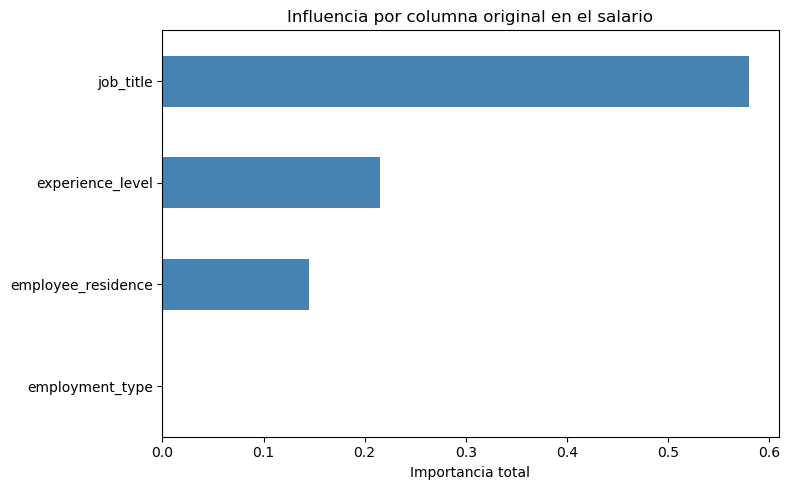

In [84]:
importances = model.feature_importances_
feature_names = X_train_scaled.columns

feat_imp = pd.DataFrame({
    'feature':    feature_names,
    'importance': importances
}).sort_values('importance', ascending=False).head(15) 

orig_cols = ['experience_level', 'employment_type', 'job_title',
             'employee_residence']

grouped = {}
for col in orig_cols:
    mask = feat_imp['feature'].str.startswith(col)
    grouped[col] = feat_imp.loc[mask, 'importance'].sum()

grouped_df = pd.Series(grouped).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
grouped_df.plot(kind='barh', color='steelblue')
plt.xlabel('Importancia total')
plt.title('Influencia por columna original en el salario')
plt.tight_layout()
plt.show()